In [1]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import warnings



warnings.filterwarnings('ignore')

In [2]:
# --- 1. DATA LOADING AND UNIFICATION ---

def load_and_unify_data(spp_filepath, kinematic_filepath):
    """
    Loads SPP and Kinematic data, aligns them, calculates differences,
    and returns a single unified DataFrame using explicit column names.
    """
    try:
        spp_df = pd.read_csv(spp_filepath)
        kin_df = pd.read_csv(kinematic_filepath)
        print(f"✓ SPP file loaded with {len(spp_df)} rows.")
        print(f"✓ Kinematic file loaded with {len(kin_df)} rows.")
    except Exception as e:
        print(f"✗ Error loading files: {e}")
        return None, None, None, None, None

    spp_df['GPST'] = pd.to_datetime(spp_df['GPST']).dt.floor('S')
    kin_df['GPST'] = pd.to_datetime(kin_df['GPST']).dt.floor('S')

    c = pd.merge(spp_df, kin_df, how='inner', on='GPST')

    unified_df = c.copy()

    unified_df['diff_x'] = unified_df['x_y'] - unified_df['x_x']
    unified_df['diff_y'] = unified_df['y_y'] - unified_df['y_x']
    unified_df['diff_z'] = unified_df['z_y'] - unified_df['z_x']

    feature_cols = ['x_x', 'y_x', 'z_x', 'ns', 'sdx(m)', 'sdy(m)', 'sdz(m)']

    return unified_df, feature_cols, 'x_x', 'y_x', 'z_x'

In [3]:

# --- 5. MAIN EXECUTION ---

spp_filepath = r'F:\zizo\RTKCorrection\src\research\SPP_6_EW_EVENING.csv'
kinematic_filepath = r'F:\zizo\RTKCorrection\src\research\Kinematic_6_EW_EVENING.csv'
    # 1) step is to return merged data
unified_df1, feature_cols, spp_x, spp_y, spp_z = load_and_unify_data(spp_filepath, kinematic_filepath)
len(unified_df1)

✓ SPP file loaded with 15493 rows.
✓ Kinematic file loaded with 15264 rows.


15234

In [4]:
spp_filepath = r'F:\zizo\RTKCorrection\src\research\SPP_6_EW_MORNING.csv'
kinematic_filepath = r'F:\zizo\RTKCorrection\src\research\Kinematic_6_EW_MORNING.csv'
    # 1) step is to return merged data
unified_df2, feature_cols, spp_x, spp_y, spp_z = load_and_unify_data(spp_filepath, kinematic_filepath)
len(unified_df2)

✓ SPP file loaded with 15225 rows.
✓ Kinematic file loaded with 15035 rows.


15035

In [5]:
spp_filepath = r'F:\zizo\RTKCorrection\src\research\SPP_6_NS_EVENING.csv'
kinematic_filepath = r'F:\zizo\RTKCorrection\src\research\Kinematic_6_NS_EVENING.csv'
    # 1) step is to return merged data
unified_df3, feature_cols, spp_x, spp_y, spp_z = load_and_unify_data(spp_filepath, kinematic_filepath)
len(unified_df3)

✓ SPP file loaded with 14766 rows.
✓ Kinematic file loaded with 14265 rows.


14257

In [6]:
spp_filepath = r'F:\zizo\RTKCorrection\src\research\SPP_6_NS_MORNING.csv'
kinematic_filepath = r'F:\zizo\RTKCorrection\src\research\Kinematic_6_NS_MORNING.csv'
    # 1) step is to return merged data
unified_df4, feature_cols, spp_x, spp_y, spp_z = load_and_unify_data(spp_filepath, kinematic_filepath)
len(unified_df4)

✓ SPP file loaded with 14700 rows.
✓ Kinematic file loaded with 13931 rows.


13928

In [7]:
# Append all dataframes
unified_df = pd.concat([unified_df1, unified_df2, unified_df3, unified_df4], ignore_index=True)

# Sort by GPST
unified_df = unified_df.sort_values('GPST').reset_index(drop=True)

print(f"Total number of rows after appending: {len(unified_df)}")
print("\nFirst few rows to verify sorting:")
print(unified_df.head())

Total number of rows after appending: 58454

First few rows to verify sorting:
                 GPST          x_x           y_x           z_x   ns  sdx(m)  \
0 2023-12-06 01:59:02  459294.1994  5.634070e+06  2.946976e+06  8.0  5.9520   
1 2023-12-06 01:59:03  459294.5524  5.634069e+06  2.946977e+06  8.0  5.9529   
2 2023-12-06 01:59:04  459296.0134  5.634068e+06  2.946975e+06  8.0  5.9538   
3 2023-12-06 01:59:05  459297.1046  5.634067e+06  2.946975e+06  8.0  5.9547   
4 2023-12-06 01:59:06  459297.6971  5.634067e+06  2.946975e+06  8.0  5.9556   

   sdy(m)  sdz(m)          x_y           y_y           z_y   diff_x   diff_y  \
0  7.1054  7.9688  459309.4422  5.634052e+06  2.946962e+06  15.2428 -18.2920   
1  7.1062  7.9688  459319.0262  5.634041e+06  2.946962e+06  24.4738 -27.9242   
2  7.1070  7.9687  459317.0929  5.634043e+06  2.946962e+06  21.0795 -25.6107   
3  7.1078  7.9687  459317.2985  5.634042e+06  2.946963e+06  20.1939 -24.8154   
4  7.1086  7.9687  459319.0294  5.634041e+06  

In [8]:
# --- 2. MODEL TRAINING AND EVALUATION ---

def train_ensemble_and_evaluate(unified_df, feature_cols):
    # --- Data prep ---
    X = unified_df[feature_cols]
    y = unified_df[['diff_x', 'diff_y', 'diff_z']]

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    X_train_scaled = x_scaler.fit_transform(X_train)
    X_test_scaled = x_scaler.transform(X_test)
    y_train_scaled = y_scaler.fit_transform(y_train)
    y_test_scaled = y_scaler.transform(y_test)

    # --- Train Random Forest Regressor ---
    print(f"\n{'='*80}\nTraining Random Forest Regressor\n{'='*80}")
    
    rf_model = RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )
    
    rf_model.fit(X_train_scaled, y_train_scaled)

    # --- Make predictions ---
    y_pred_scaled = rf_model.predict(X_test_scaled)
    y_pred = y_scaler.inverse_transform(y_pred_scaled)
    y_test_vals = y_test.values

    # --- Evaluation ---
    print("\n" + "="*80 + "\nFINAL EVALUATION: RANDOM FOREST MODEL\n" + "="*80)
    per_axis_rmse = []
    for i, axis in enumerate(['X', 'Y', 'Z']):
        rmse = np.sqrt(mean_squared_error(y_test_vals[:, i], y_pred[:, i]))
        per_axis_rmse.append(rmse)
        print(f"--- Axis {axis} ---\n  R² Score: {r2_score(y_test_vals[:, i], y_pred[:, i]):.4f}\n  RMSE (m): {rmse:.4f}\n")

    overall_rmse = np.mean(per_axis_rmse)
    print(f"Overall mean RMSE (m): {overall_rmse:.4f}")

    # --- Plot feature importance ---
    plt.figure(figsize=(10, 6))
    feature_importance = rf_model.feature_importances_
    indices = np.argsort(feature_importance)[::-1]
    
    plt.title("Random Forest Feature Importance",fontsize=18)
    plt.bar(range(len(feature_importance)), feature_importance[indices],color='skyblue')
    plt.xticks(range(len(feature_importance)), [feature_cols[i] for i in indices], rotation=45)
    plt.tight_layout()
    plt.show()

    return rf_model, x_scaler, y_scaler, X_test, y_pred

In [9]:
# --- 3. ACCURACY IMPROVEMENT ANALYSIS ---

def calculate_accuracy_improvement(test_df, y_pred_corrected, spp_cols):
    """Calculates and prints the before-and-after 3D error comparison."""
    spp_x_col, spp_y_col, spp_z_col = spp_cols

    # Original 3D Error from diff_x, diff_y, diff_z
    original_3d_errors = np.sqrt(test_df['diff_x']**2 + test_df['diff_y']**2 + test_df['diff_z']**2)
    mean_original_error = original_3d_errors.mean()

    # Corrected 3D Error = x_x + correction using AI
    corrected_spp_x = test_df[spp_x_col] + y_pred_corrected[:, 0]
    corrected_spp_y = test_df[spp_y_col] + y_pred_corrected[:, 1]
    corrected_spp_z = test_df[spp_z_col] + y_pred_corrected[:, 2]

    # overall error for improvement_distnace = testing_kinematic -  Corrected 3D Error
    corrected_diff_x = test_df['x_y'] - corrected_spp_x
    corrected_diff_y = test_df['y_y'] - corrected_spp_y
    corrected_diff_z = test_df['z_y'] - corrected_spp_z

    corrected_3d_errors = np.sqrt(corrected_diff_x**2 + corrected_diff_y**2 + corrected_diff_z**2)
    mean_corrected_error = corrected_3d_errors.mean()

    improvement = mean_original_error - mean_corrected_error
    improvement_percent = (improvement / mean_original_error) * 100 if mean_original_error != 0 else 0

    print("\n" + "="*80 + "\nMODEL ACCURACY IMPROVEMENT ANALYSIS\n" + "="*80)
    print(f"Mean 3D Error (Original): {mean_original_error:.4f} m")
    print(f"Mean 3D Error (Corrected): {mean_corrected_error:.4f} m")
    print(f"\nImprovement: {improvement:.4f} m ({improvement_percent:.2f}%)")

In [10]:
unified_df[['diff_x','diff_y','diff_z']].describe()

,diff_x,diff_y,diff_z
count,58454.000000,58454.000000,58454.000000
mean,-2.858968,-15.660449,-12.837220
std,4.159549,10.024231,5.554226
min,-63.905400,-95.476500,-47.472100
25%,-4.723275,-19.960175,-16.443275
50%,-2.439200,-14.907950,-12.828450
75%,-0.457600,-10.052900,-8.678900
max,45.448800,115.827800,26.333700


In [11]:
from sklearn.ensemble import IsolationForest

# Ensure diff columns exist
cols = ['diff_x', 'diff_y', 'diff_z']
missing = [c for c in cols if c not in unified_df.columns]
if missing:
    raise KeyError(f'Missing required diff columns in unified_df: {missing}')

# Handle NaNs directly in unified_df (fill with median)
unified_df[cols] = unified_df[cols].fillna(unified_df[cols].median())

# Train IsolationForest on the diff columns
iso = IsolationForest(
    n_estimators=200,
    contamination='auto',
    random_state=42,
    n_jobs=-1
)
iso.fit(unified_df[cols])

# Predict anomalies (-1 = anomaly, 1 = normal)
unified_df['anomaly'] = iso.predict(unified_df[cols])

# Print summary
print('Anomaly value counts (1 = normal, -1 = anomaly):')
print(unified_df['anomaly'].value_counts())


Anomaly value counts (1 = normal, -1 = anomaly):
anomaly
 1    51525
-1     6929
Name: count, dtype: int64


In [12]:
unified_df = unified_df[unified_df['anomaly'] == 1].drop(columns=['anomaly'])
print(f"Data size before cleaning: {len(unified_df)}")

Data size before cleaning: 51525


In [15]:
unified_df[['diff_x', 'diff_y', 'diff_z']].describe()

,diff_x,diff_y,diff_z
count,51525.000000,51525.000000,51525.000000
mean,-2.563486,-14.810779,-12.285122
std,2.634820,6.548240,4.327309
min,-12.755100,-39.800300,-23.967100
25%,-4.396600,-19.177200,-15.915700
50%,-2.345400,-14.600800,-12.436600
75%,-0.518200,-10.282000,-8.671400
max,4.766200,4.382400,-0.935800



Training Random Forest Regressor

FINAL EVALUATION: RANDOM FOREST MODEL
--- Axis X ---
  R² Score: 0.7309
  RMSE (m): 1.3698

--- Axis Y ---
  R² Score: 0.6922
  RMSE (m): 3.6695

--- Axis Z ---
  R² Score: 0.8547
  RMSE (m): 1.6512

Overall mean RMSE (m): 2.2302


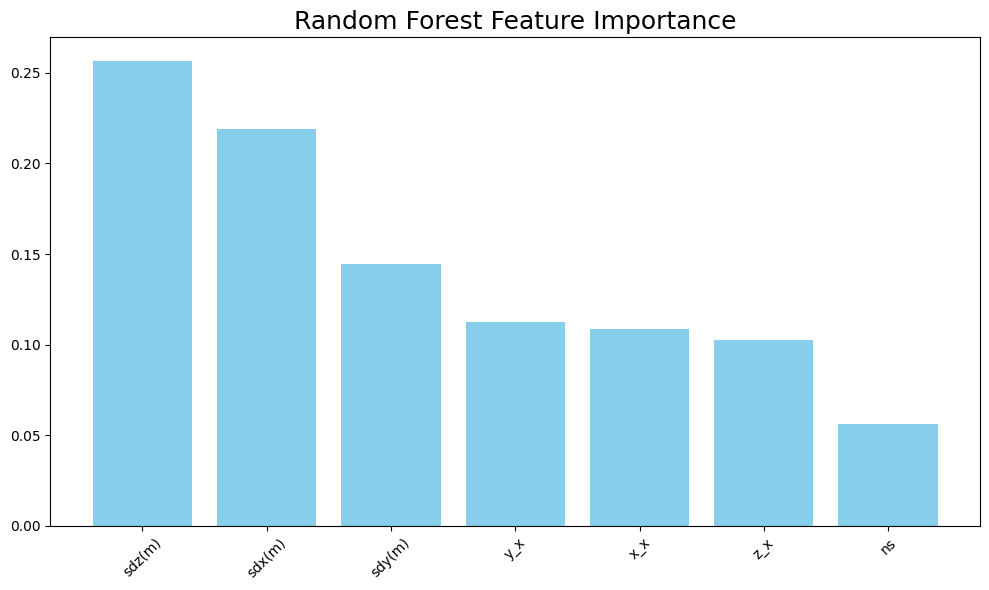


MODEL ACCURACY IMPROVEMENT ANALYSIS
Mean 3D Error (Original): 19.8966 m
Mean 3D Error (Corrected): 2.8826 m

Improvement: 17.0140 m (85.51%)


'\njoblib.dump(best_models, \'best_gnss_model.joblib\')\njoblib.dump(x_scaler, \'x_scaler.joblib\')\njoblib.dump(y_scaler, \'y_scaler.joblib\')\njoblib.dump(feature_cols, \'feature_cols.joblib\')\nprint("\n✓ Best model, scaler, and feature list saved successfully!")\nprint("\n✓ Analysis complete!")'

In [16]:
    # 2) train simple Neural Network (BatchNorm + Dropout)
    # Think of it like asking multiple experts for their opinion and averaging their answers.
best_models, x_scaler, y_scaler, X_test, y_pred = train_ensemble_and_evaluate(unified_df, feature_cols)
test_df = unified_df.loc[X_test.index]

calculate_accuracy_improvement(test_df, y_pred, (spp_x, spp_y, spp_z))
"""
    joblib.dump(best_models, 'best_gnss_model.joblib')
    joblib.dump(x_scaler, 'x_scaler.joblib')
    joblib.dump(y_scaler, 'y_scaler.joblib')
    joblib.dump(feature_cols, 'feature_cols.joblib')
    print("\n✓ Best model, scaler, and feature list saved successfully!")
    print("\n✓ Analysis complete!")"""

above is the data with iono correction

# **Plotting**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

# ====================================================
# 1. LOAD DATA
# ====================================================
spp_path = r"F:\zizo\RTKCorrection\src\research\extracted_coordinates_x_b_IONO.csv"
kin_path = r"F:\zizo\RTKCorrection\src\research\extracted_coordinates_y_b_IONO.csv"

spp_df = pd.read_csv(spp_path)
kin_df = pd.read_csv(kin_path)

# ====================================================
# 2. MERGE BY GPST (EXACT TO SECOND)
# ====================================================
spp_df['GPST'] = pd.to_datetime(spp_df['GPST']).dt.floor('S')
kin_df['GPST'] = pd.to_datetime(kin_df['GPST']).dt.floor('S')

c = pd.merge(spp_df, kin_df, how='inner', on='GPST')
unified_df = c.copy()

print(f"✓ SPP file loaded with {len(spp_df)} rows.")
print(f"✓ Kinematic file loaded with {len(kin_df)} rows.")
print(f"✓ Data aligned with {len(unified_df)} rows (inner join on GPST).")

# ====================================================
# 3. CLEAN COLUMN NAMES (to avoid saving errors)
# ====================================================
def clean_column_name(name):
    name = re.sub(r'[^A-Za-z0-9_]+', '_', name)
    return name.strip('_')

unified_df.columns = [clean_column_name(c) for c in unified_df.columns]

# ====================================================
# 4. CREATE OUTPUT DIRECTORY
# ====================================================
out_dir = "analysis_outputs"
os.makedirs(out_dir, exist_ok=True)

# ====================================================
# 5. DIFFERENCE COLUMNS (if applicable)
# ====================================================
# Detect coordinate columns (commonly x, y, z)
x_cols = [c for c in unified_df.columns if re.search(r'x', c, re.IGNORECASE)]
y_cols = [c for c in unified_df.columns if re.search(r'y', c, re.IGNORECASE)]
z_cols = [c for c in unified_df.columns if re.search(r'z', c, re.IGNORECASE)]

# Create difference columns for known coordinate pairs
if 'x_x' in unified_df.columns and 'x_y' in unified_df.columns:
    unified_df['diff_x'] = unified_df['x_y'] - unified_df['x_x']
if 'y_x' in unified_df.columns and 'y_y' in unified_df.columns:
    unified_df['diff_y'] = unified_df['y_y'] - unified_df['y_x']
if 'z_x' in unified_df.columns and 'z_y' in unified_df.columns:
    unified_df['diff_z'] = unified_df['z_y'] - unified_df['z_x']

# ====================================================
# 6. DESCRIPTIVE STATISTICS
# ====================================================
desc_stats = unified_df.describe().T
desc_stats.to_csv(f"{out_dir}/descriptive_statistics.csv")
print("✓ Descriptive statistics saved.")

# ====================================================
# 7. VISUALIZATION FUNCTIONS
# ====================================================

def plot_distributions(df, out_dir):
    """Plot distributions for all numeric columns."""
    for col in df.columns:
        if col == 'GPST' or not np.issubdtype(df[col].dtype, np.number):
            continue
        plt.figure(figsize=(8,5))
        sns.histplot(df[col], kde=True, bins=50)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.tight_layout()
        plt.savefig(f"{out_dir}/dist_{col}.png")
        plt.close()

def plot_boxplots(df, out_dir):
    """Plot boxplots for all numeric columns."""
    for col in df.columns:
        if col == 'GPST' or not np.issubdtype(df[col].dtype, np.number):
            continue
        plt.figure(figsize=(6,4))
        sns.boxplot(x=df[col])
        plt.title(f'Boxplot of {col}')
        plt.tight_layout()
        plt.savefig(f"{out_dir}/box_{col}.png")
        plt.close()

def plot_time_series(df, out_dir):
    """Plot time series for all numeric columns."""
    for col in df.columns:
        if col == 'GPST' or not np.issubdtype(df[col].dtype, np.number):
            continue
        plt.figure(figsize=(10,5))
        plt.plot(df['GPST'], df[col], linewidth=1)
        plt.title(f'Time Series of {col}')
        plt.xlabel('GPST')
        plt.ylabel(col)
        plt.tight_layout()
        plt.savefig(f"{out_dir}/time_{col}.png")
        plt.close()

def plot_differences(df, out_dir):
    """Plot histograms and time series of diff_x, diff_y, diff_z."""
    diff_cols = [c for c in df.columns if c.startswith('diff_')]
    for col in diff_cols:
        plt.figure(figsize=(8,5))
        sns.histplot(df[col], kde=True, bins=50, color='skyblue')
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.tight_layout()
        plt.savefig(f"{out_dir}/diff_dist_{col}.png")
        plt.close()

        plt.figure(figsize=(10,5))
        plt.plot(df['GPST'], df[col], linewidth=1, color='green')
        plt.title(f'Time Series of {col}')
        plt.xlabel('GPST')
        plt.ylabel(col)
        plt.tight_layout()
        plt.savefig(f"{out_dir}/diff_time_{col}.png")
        plt.close()

# ====================================================
# 8. PLOTTING
# ====================================================
plot_distributions(unified_df, out_dir)
plot_boxplots(unified_df, out_dir)
plot_time_series(unified_df, out_dir)
plot_differences(unified_df, out_dir)

# ====================================================
# 9. CORRELATION HEATMAP
# ====================================================
plt.figure(figsize=(10,8))
corr = unified_df.select_dtypes(include=[np.number]).corr()
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap (All Numeric Columns)")
plt.tight_layout()
plt.savefig(f"{out_dir}/correlation_heatmap.png")
plt.close()

print(f"✓ Deep EDA and plots saved to folder: {out_dir}/")


C:\Users\User\AppData\Local\Temp\ipykernel_15556\319465020.py:20: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  spp_df['GPST'] = pd.to_datetime(spp_df['GPST']).dt.floor('S')
C:\Users\User\AppData\Local\Temp\ipykernel_15556\319465020.py:21: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  kin_df['GPST'] = pd.to_datetime(kin_df['GPST']).dt.floor('S')


✓ SPP file loaded with 7962 rows.
✓ Kinematic file loaded with 7910 rows.
✓ Data aligned with 7910 rows (inner join on GPST).
✓ Descriptive statistics saved.
✓ Deep EDA and plots saved to folder: analysis_outputs/
